# Social Media Engagement Analytics Using Python

## Module-End Assignment 5

This project analyzes social media engagement data using Python, NumPy, Pandas, Matplotlib, Seaborn, and Plotly.

The analysis includes data cleaning, transformation, exploratory data analysis, statistical analysis, data visualization, and business insights.

### Task 1 — Data Import & Setup

In [ ]:
# ============================================
# TASK 1 – DATA IMPORT & SETUP
# Import Required Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================
# Load Dataset
# ============================================

from google.colab import files

uploaded = files.upload()

In [ ]:
# Load the CSV dataset

df = pd.read_csv("social_media_engagement_5000.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 5000
Number of columns: 19


In [ ]:
# ============================================
# Initial Dataset Inspection
# ============================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (5000, 19)

Column Names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

First 5 Rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372



Last 5 Rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
# ============================================
# Check Data Types
# ============================================

print("Dataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         485

In [ ]:
# ============================================
# Convert Date Column
# ============================================

df["posted_at"] = pd.to_datetime(
    df["posted_at"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("posted_at data type:", df["posted_at"].dtype)
print("Invalid/missing dates:", df["posted_at"].isna().sum())

posted_at data type: datetime64[ns]
Invalid/missing dates: 0


In [ ]:
# Verify watch_time_sec remains numeric

print("watch_time_sec data type:", df["watch_time_sec"].dtype)

watch_time_sec data type: int64


In [ ]:
# ============================================
# NumPy Array Operations
# ============================================

likes_array = np.array(df["likes"])

print("First 10 likes:")
print(likes_array[:10])

print("\nTotal likes:", np.sum(likes_array))
print("Average likes:", np.mean(likes_array))
print("Maximum likes:", np.max(likes_array))
print("Minimum likes:", np.min(likes_array))

First 10 likes:
[ 7011. 11750.  4862.  5350. 12682. 12535. 11703.  9611.    nan 14106.]

Total likes: nan
Average likes: nan
Maximum likes: nan
Minimum likes: nan


###Task 2 — Data Cleaning

#####In this task, we identify and handle missing values, duplicates, incorrect data types, inconsistent categories, unrealistic values, and clean feature-related fields.


In [ ]:
# ============================================
# Missing Value Detection – isnull()
# ============================================

print("Missing values using isnull():")
print(df.isnull().sum())

Missing values using isnull():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# ============================================
# Missing Value Detection – isna()
# ============================================

print("Missing values using isna():")
print(df.isna().sum())

print("\nTotal missing values:",
      df.isna().sum().sum())

Missing values using isna():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Total missing values: 900


In [ ]:
# ============================================
# Demonstration of dropna()
# A temporary DataFrame is used so the main
# dataset is not unnecessarily reduced.
# ============================================

sample_df = df[["age", "likes", "comments"]].dropna()

print("Rows before dropna():", len(df))
print("Rows after dropna():", len(sample_df))

Rows before dropna(): 5000
Rows after dropna(): 4566


In [ ]:
# ============================================
# Handle Numerical Missing Values
# Using Median
# ============================================

numeric_missing_columns = [
    "age",
    "likes",
    "comments",
    "shares"
]

for column in numeric_missing_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Numerical missing values handled using median.")

Numerical missing values handled using median.


In [ ]:
# ============================================
# Handle Categorical Missing Values
# Using Mode
# ============================================

categorical_missing_columns = [
    "gender",
    "sentiment"
]

for column in categorical_missing_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

print("Categorical missing values handled using mode.")

Categorical missing values handled using mode.


In [ ]:
# ============================================
# Demonstration of Forward Fill and Backward Fill
# ============================================

fill_demo = df[["age", "likes"]].copy()

forward_filled = fill_demo.ffill()
backward_filled = fill_demo.bfill()

print("Forward-fill demonstration:")
display(forward_filled.head())

print("\nBackward-fill demonstration:")
display(backward_filled.head())

Forward-fill demonstration:


,age,likes
0,43.0,7011.0
1,33.0,11750.0
2,32.0,4862.0
3,51.0,5350.0
4,34.0,12682.0



Backward-fill demonstration:


,age,likes
0,43.0,7011.0
1,33.0,11750.0
2,32.0,4862.0
3,51.0,5350.0
4,34.0,12682.0


In [ ]:
# ============================================
# Verify Missing Values After Cleaning
# ============================================

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

Missing values after cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

Total missing values: 0


In [ ]:
# ============================================
# Identify Duplicate Rows
# ============================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:",
      duplicate_count)

Duplicate rows before removal: 0


In [ ]:
# ============================================
# Remove Duplicate Rows
# ============================================

df = df.drop_duplicates()

print("Duplicate rows after removal:",
      df.duplicated().sum())

Duplicate rows after removal: 0


In [ ]:
# ============================================
# Standardize Categorical Values
# ============================================

categorical_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


In [ ]:
# ============================================
# Check for Unrealistic Engagement Values
# ============================================

engagement_columns = [
    "likes",
    "comments",
    "shares"
]

for column in engagement_columns:
    negative_values = (df[column] < 0).sum()

    print(
        f"{column}: {negative_values} negative values"
    )

likes: 0 negative values
comments: 0 negative values
shares: 0 negative values


In [ ]:
# ============================================
# Correct Unrealistic Negative Values
# ============================================

for column in engagement_columns:

    # Convert negative values to missing
    df.loc[df[column] < 0, column] = np.nan

    # Replace resulting missing values with median
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Unrealistic engagement values handled successfully.")

Unrealistic engagement values handled successfully.


In [ ]:
# ============================================
# Extract Hashtag Count
# ============================================

df["hashtag_count"] = (
    df["hashtags"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

print("Hashtag count created successfully.")

display(
    df[["hashtags", "hashtag_count"]].head(10)
)

Hashtag count created successfully.


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [ ]:
# ============================================
# Create Engagement Score
# ============================================

df["engagement_score"] = (
    df["likes"]
    + df["comments"]
    + df["shares"]
)

print("Engagement score created successfully.")

Engagement score created successfully.


In [ ]:
# ============================================
# Clean Sentiment Labels
# ============================================

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Sentiment categories:")
print(df["sentiment"].value_counts())

Sentiment categories:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


### Task 3 — Data Exploration using Pandas

In [ ]:
# ============================================
# Dataset Structure
# ============================================

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0



Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151.0
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896.0
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3,17131.0



Dataset shape:
(5000, 21)

Column names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score']


In [ ]:
# ============================================
# Dataset Information and Data Types
# ============================================

print("Dataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_

In [ ]:
# ============================================
# Summary Statistics
# ============================================

display(df.describe())

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count,engagement_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.00000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600,12611.94780
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000,193.00000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000,7807.00000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000,12551.75000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000,17478.25000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000,24680.00000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853,5782.05846


In [ ]:
# ============================================
# Categorical Distribution Analysis
# ============================================

print("Gender Distribution:")
print(df["gender"].value_counts())

print("\nPost Type Distribution:")
print(df["post_type"].value_counts())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nDevice Type Distribution:")
print(df["device_type"].value_counts())

Gender Distribution:
gender
male      1849
other     1581
female    1570
Name: count, dtype: int64

Post Type Distribution:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Sentiment Distribution:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Device Type Distribution:
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64


In [ ]:
# ============================================
# Unique Values and Number of Unique Values
# ============================================

categorical_analysis_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for column in categorical_analysis_columns:

    print("\n" + "=" * 50)
    print("Column:", column)

    print("Unique values:")
    print(df[column].unique())

    print("Number of unique values:")
    print(df[column].nunique())


Column: gender
Unique values:
['female' 'male' 'other']
Number of unique values:
3

Column: country
Unique values:
['brazil' 'uk' 'france' 'canada' 'japan' 'australia' 'india' 'uae'
 'germany' 'usa']
Number of unique values:
10

Column: post_type
Unique values:
['image' 'reel' 'text' 'video']
Number of unique values:
4

Column: post_category
Unique values:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Number of unique values:
8

Column: device_type
Unique values:
['mobile' 'tablet' 'desktop']
Number of unique values:
3

Column: sentiment
Unique values:
['negative' 'positive' 'neutral']
Number of unique values:
3


In [ ]:
# ============================================
# Correlation Matrix for Numeric Fields
# ============================================

numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

display(correlation_matrix)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count,engagement_score
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692,0.021868
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173,-0.035531
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344,0.012947
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190,0.983942
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230,0.130552
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379,0.104285
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301,0.007616
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714,0.005937
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802,-0.025467
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319,0.094382


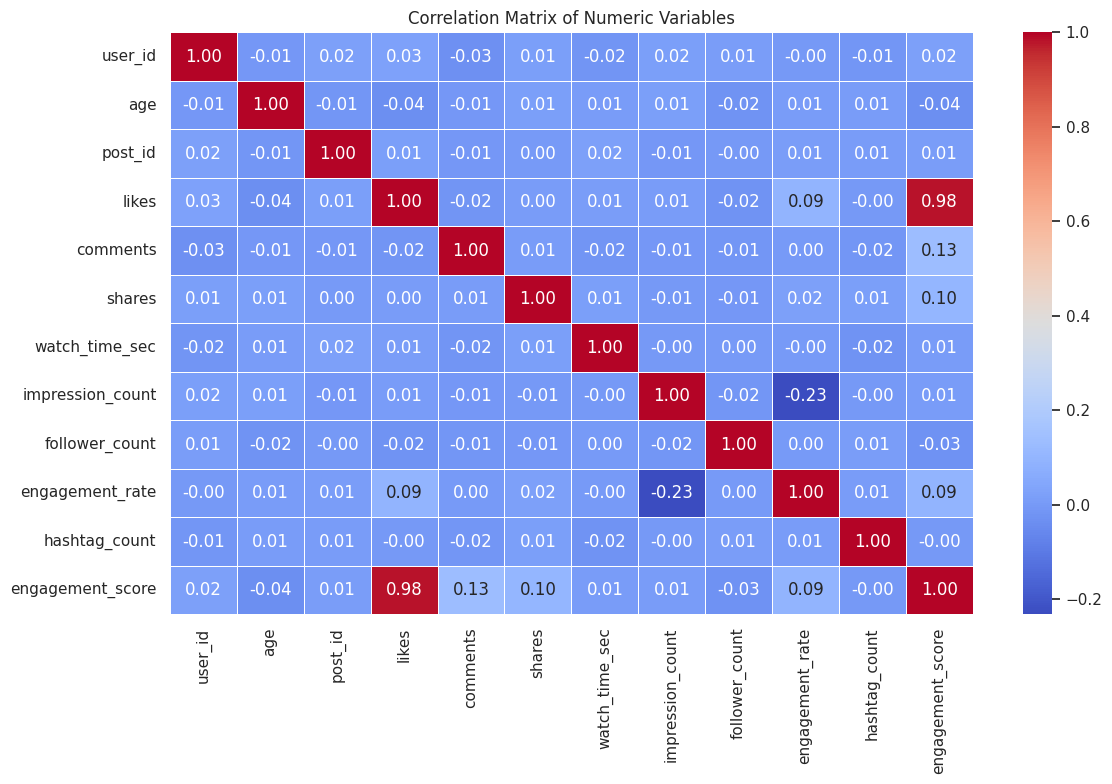

In [ ]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# GroupBy Analysis
# ============================================

print("Average Likes by Post Type:")
display(
    df.groupby("post_type")["likes"]
      .mean()
      .sort_values(ascending=False)
)

print("\nAverage Impressions by Country:")
display(
    df.groupby("country")["impression_count"]
      .mean()
      .sort_values(ascending=False)
)

print("\nAverage Engagement Score by Sentiment:")
display(
    df.groupby("sentiment")["engagement_score"]
      .mean()
      .sort_values(ascending=False)
)

Average Likes by Post Type:


,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416



Average Impressions by Country:


,impression_count
country,
india,52462.386916
france,51727.673387
usa,51263.872255
uk,51119.393509
japan,49616.135593
brazil,49193.174603
uae,48928.413519
canada,48703.150097
germany,48605.406122



Average Engagement Score by Sentiment:


,engagement_score
sentiment,
negative,12731.498958
positive,12665.799443
neutral,12448.163720


### Task 4 — Data Wrangling  

In [ ]:
# ============================================
# Data Wrangling – New Fields
# ============================================

print("New fields created:")
print([
    "engagement_score",
    "hashtag_count"
])

display(
    df[
        [
            "likes",
            "comments",
            "shares",
            "engagement_score",
            "hashtags",
            "hashtag_count"
        ]
    ].head(10)
)

New fields created:
['engagement_score', 'hashtag_count']


,likes,comments,shares,engagement_score,hashtags,hashtag_count
0,7011.0,354.0,1157.0,8522.0,#foodie #travel #love,3
1,11750.0,2606.0,1807.0,16163.0,#fitness,1
2,4862.0,344.0,955.0,6161.0,#foodie,1
3,5350.0,1083.0,1049.0,7482.0,#music #foodie #fun,3
4,12682.0,2735.0,1300.0,16717.0,#travel,1
5,12535.0,1790.0,99.0,14424.0,#fitness,1
6,11703.0,2276.0,1465.0,15444.0,#music,1
7,9611.0,146.0,424.0,10181.0,#travel #music #fitness,3
8,10105.5,2379.0,1897.0,14381.5,#music #fun #fitness,3
9,14106.0,2480.0,1053.0,17639.0,#lifestyle #love,2


In [ ]:
# ============================================
# Date-Based Feature Engineering
# ============================================

df["year"] = df["posted_at"].dt.year
df["month"] = df["posted_at"].dt.month
df["month_name"] = df["posted_at"].dt.month_name()
df["day_of_week"] = df["posted_at"].dt.day_name()

display(
    df[
        [
            "posted_at",
            "year",
            "month",
            "month_name",
            "day_of_week"
        ]
    ].head()
)

,posted_at,year,month,month_name,day_of_week
0,2022-12-17,2022,12,December,Saturday
1,2023-06-02,2023,6,June,Friday
2,2023-05-07,2023,5,May,Sunday
3,2023-02-12,2023,2,February,Sunday
4,2023-05-23,2023,5,May,Tuesday


In [ ]:
# ============================================
# GroupBy Summary – Post Type
# ============================================

post_type_summary = (
    df.groupby("post_type")
      .agg(
          average_likes=("likes", "mean"),
          average_comments=("comments", "mean"),
          average_shares=("shares", "mean"),
          average_engagement=("engagement_score", "mean")
      )
      .sort_values(
          "average_engagement",
          ascending=False
      )
)

display(post_type_summary)

,average_likes,average_comments,average_shares,average_engagement
post_type,,,,
video,10188.600000,1479.160000,996.834286,12664.594286
image,10104.865277,1525.235766,1019.289495,12649.390537
text,10100.148193,1499.106024,1013.989558,12613.243775
reel,10037.802416,1504.187062,982.042089,12524.031567


In [ ]:
# ============================================
# GroupBy Summary – Country
# ============================================

country_summary = (
    df.groupby("country")
      .agg(
          average_impressions=("impression_count", "mean"),
          average_likes=("likes", "mean"),
          average_engagement=("engagement_score", "mean")
      )
      .sort_values(
          "average_impressions",
          ascending=False
      )
)

display(country_summary)

,average_impressions,average_likes,average_engagement
country,,,
india,52462.386916,9962.468224,12492.701869
france,51727.673387,10372.876008,12903.384073
usa,51263.872255,10122.361277,12575.461078
uk,51119.393509,9935.650101,12384.374239
japan,49616.135593,10088.862288,12578.648305
brazil,49193.174603,9886.689484,12385.983135
uae,48928.413519,10227.487078,12757.777336
canada,48703.150097,10063.066277,12605.894737
germany,48605.406122,10130.458163,12635.664286


In [ ]:
# ============================================
# GroupBy Summary – Sentiment
# ============================================

sentiment_summary = (
    df.groupby("sentiment")
      .agg(
          post_count=("post_id", "count"),
          average_likes=("likes", "mean"),
          average_comments=("comments", "mean"),
          average_shares=("shares", "mean"),
          average_engagement=("engagement_score", "mean")
      )
      .sort_values(
          "average_engagement",
          ascending=False
      )
)

display(sentiment_summary)

,post_count,average_likes,average_comments,average_shares,average_engagement
sentiment,,,,,
negative,960,10208.096875,1516.094792,1007.307292,12731.498958
positive,2513,10180.062077,1480.650617,1005.086749,12665.799443
neutral,1527,9923.194499,1528.404060,996.565160,12448.163720


In [ ]:
# ============================================
# Merge DataFrames
# Add Country-Level Average Impressions
# ============================================

country_impression_summary = (
    df.groupby("country", as_index=False)
      .agg(
          country_avg_impressions=(
              "impression_count",
              "mean"
          )
      )
)

df = df.merge(
    country_impression_summary,
    on="country",
    how="left"
)

print("DataFrames merged successfully.")

display(
    df[
        [
            "country",
            "impression_count",
            "country_avg_impressions"
        ]
    ].head()
)

DataFrames merged successfully.


,country,impression_count,country_avg_impressions
0,brazil,44650,49193.174603
1,brazil,80216,49193.174603
2,uk,44858,51119.393509
3,france,70455,51727.673387
4,uk,6019,51119.393509


###step5-statistical Analysis

In [ ]:
# ============================================
# Statistical Analysis
# Required Numeric Variables
# ============================================

stat_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

print("Variables selected for statistical analysis:")
print(stat_columns)

Variables selected for statistical analysis:
['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']


In [ ]:
# ============================================
# Mean, Median, Mode,
# Standard Deviation and Variance
# ============================================

statistics_summary = pd.DataFrame(
    index=stat_columns
)

statistics_summary["Mean"] = df[stat_columns].mean()
statistics_summary["Median"] = df[stat_columns].median()
statistics_summary["Mode"] = df[stat_columns].mode().iloc[0]
statistics_summary["Standard Deviation"] = df[stat_columns].std()
statistics_summary["Variance"] = df[stat_columns].var()

display(statistics_summary)

,Mean,Median,Mode,Standard Deviation,Variance
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10


In [ ]:
# ============================================
# Percentile Analysis
# ============================================

percentiles = df[stat_columns].quantile(
    [0.25, 0.50, 0.75]
)

percentiles.index = [
    "25th Percentile",
    "50th Percentile",
    "75th Percentile"
]

display(percentiles)

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
25th Percentile,5235.0,792.00,511.0,2017.75,0.145781,194480.00
50th Percentile,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
75th Percentile,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
# ============================================
# Complete Statistical Summary
# ============================================

complete_statistics = pd.DataFrame(index=stat_columns)

complete_statistics["Mean"] = df[stat_columns].mean()
complete_statistics["Median"] = df[stat_columns].median()
complete_statistics["Mode"] = df[stat_columns].mode().iloc[0]
complete_statistics["Standard Deviation"] = df[stat_columns].std()
complete_statistics["Variance"] = df[stat_columns].var()
complete_statistics["25th Percentile"] = df[stat_columns].quantile(0.25)
complete_statistics["50th Percentile"] = df[stat_columns].quantile(0.50)
complete_statistics["75th Percentile"] = df[stat_columns].quantile(0.75)

display(complete_statistics)

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000


In [ ]:
# ============================================
# FINAL DATASET VALIDATION
# ============================================

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFinal Columns:")
print(df.columns.tolist())

FINAL DATASET VALIDATION

Dataset Shape:
(5000, 26)

Total Missing Values:
0

Total Duplicate Rows:
0

Data Types:
user_id                             int64
age                               float64
gender                             object
country                            object
post_id                             int64
post_type                          object
post_category                      object
likes                             float64
comments                          float64
shares                            float64
watch_time_sec                      int64
impression_count                    int64
posted_at                  datetime64[ns]
follower_count                      int64
is_verified                          bool
device_type                        object
sentiment                          object
hashtags                           object
engagement_rate                   float64
hashtag_count                       int64
engagement_score                  float64
yea

###Visualization 1 — Likes vs Impressions

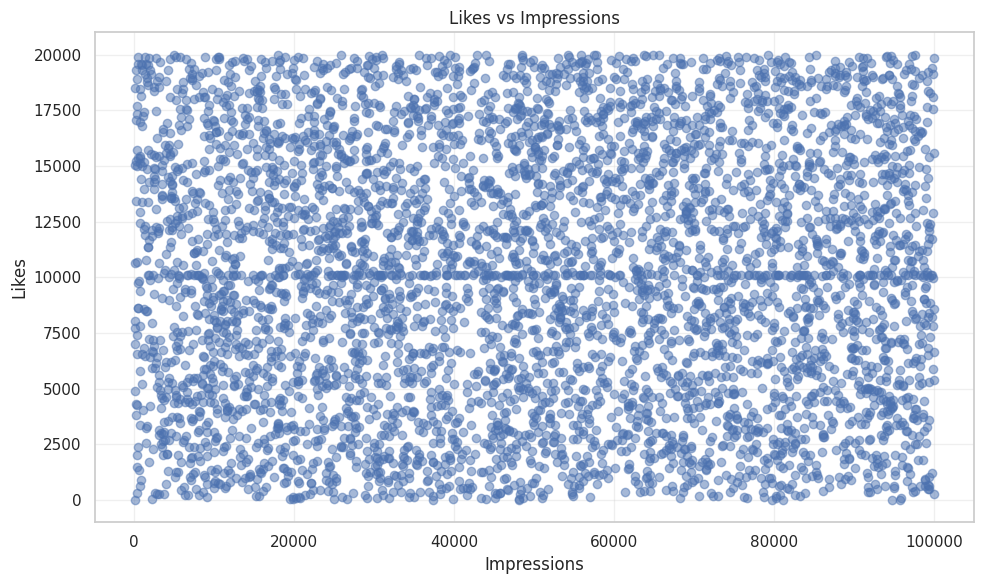

In [ ]:
# ============================================================
# PLOT 1 – SCATTER PLOT
# Likes vs Impressions
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5
)

plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

###Visualization 2 — Daily Engagement Trend

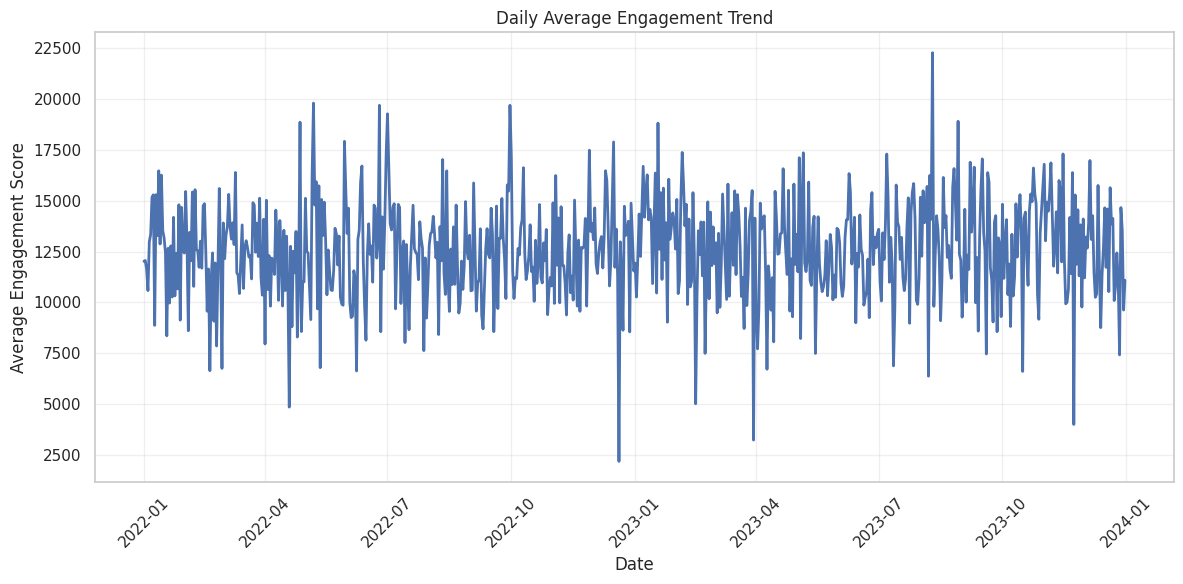

In [ ]:
# ============================================================
# PLOT 2 – LINE CHART
# Daily Engagement Trend
# ============================================================

daily_engagement = (
    df.groupby("posted_at")["engagement_score"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_engagement["posted_at"],
    daily_engagement["engagement_score"],
    linewidth=2
)

plt.title("Daily Average Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

###Visualization 3 — Posts by Category

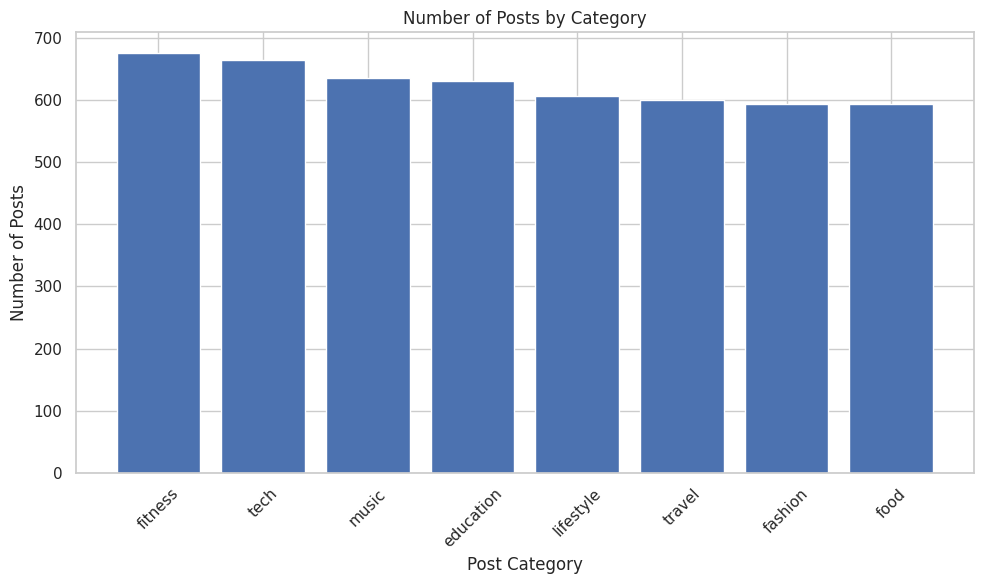

In [ ]:
# ============================================================
# PLOT 3 – BAR CHART
# Number of Posts by Category
# ============================================================

category_counts = df["post_category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Number of Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Visualization 4 — Gender Distribution

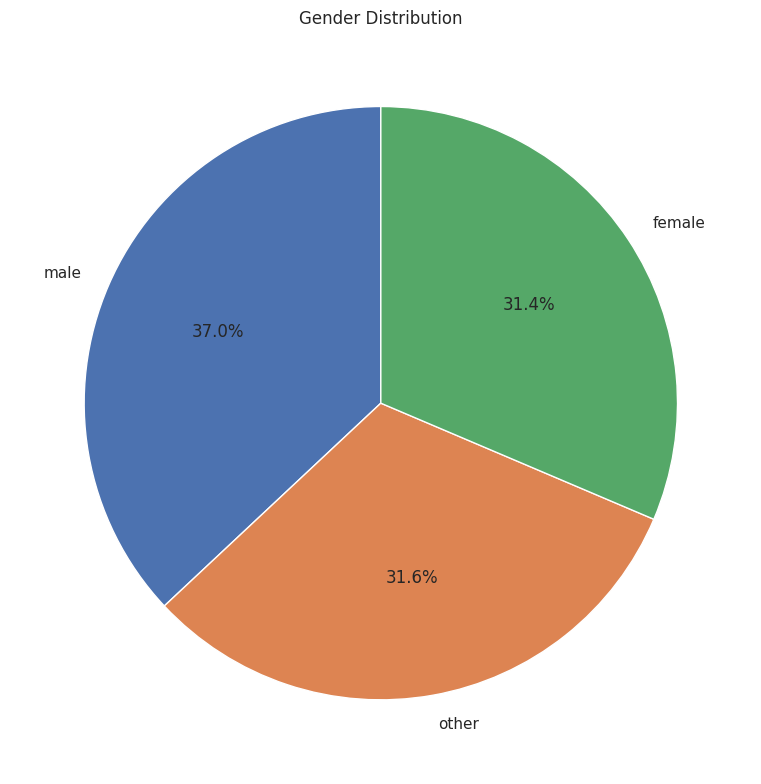

In [ ]:
# ============================================================
# PLOT 4 – PIE CHART
# Gender Distribution
# ============================================================

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.tight_layout()
plt.show()

###Visualization 5 — Age Histogram

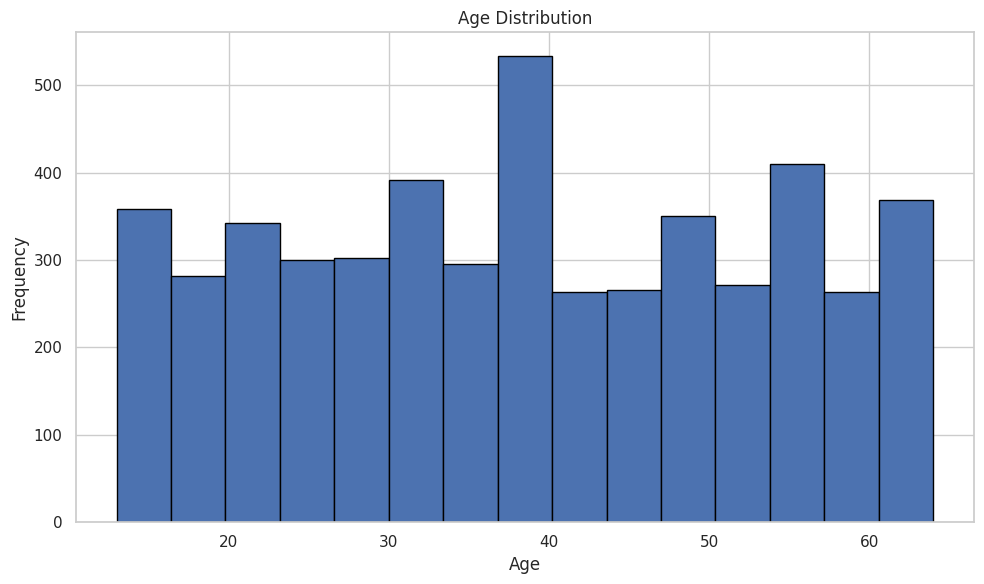

In [ ]:
# ============================================================
# PLOT 5 – HISTOGRAM
# Age Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["age"],
    bins=15,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

###Visualization 6 — Engagement Rate Box Plot

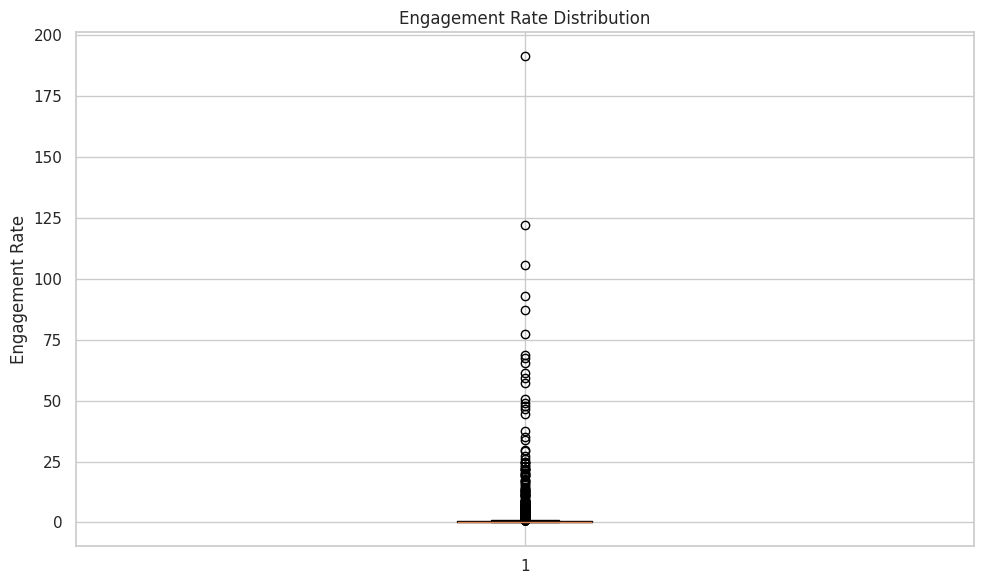

In [ ]:
# ============================================================
# PLOT 6 – BOX PLOT
# Engagement Rate Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.boxplot(
    df["engagement_rate"].dropna()
)

plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate")

plt.tight_layout()
plt.show()

###Visualization 7 — Seaborn Count Plot

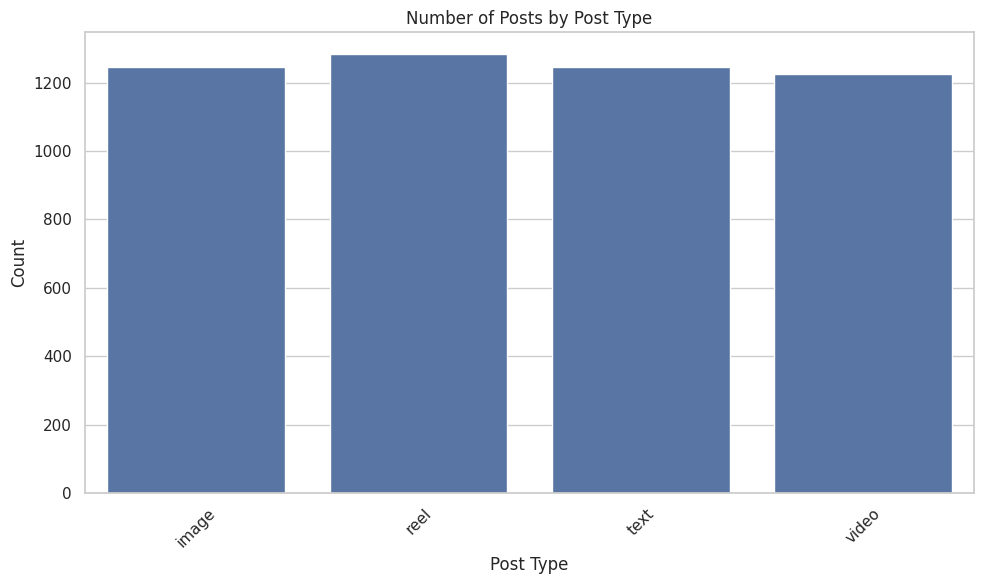

In [ ]:
# ============================================================
# PLOT 7 – SEABORN COUNT PLOT
# Number of Posts by Post Type
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="post_type"
)

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Visualization 8 — Average Likes by Category

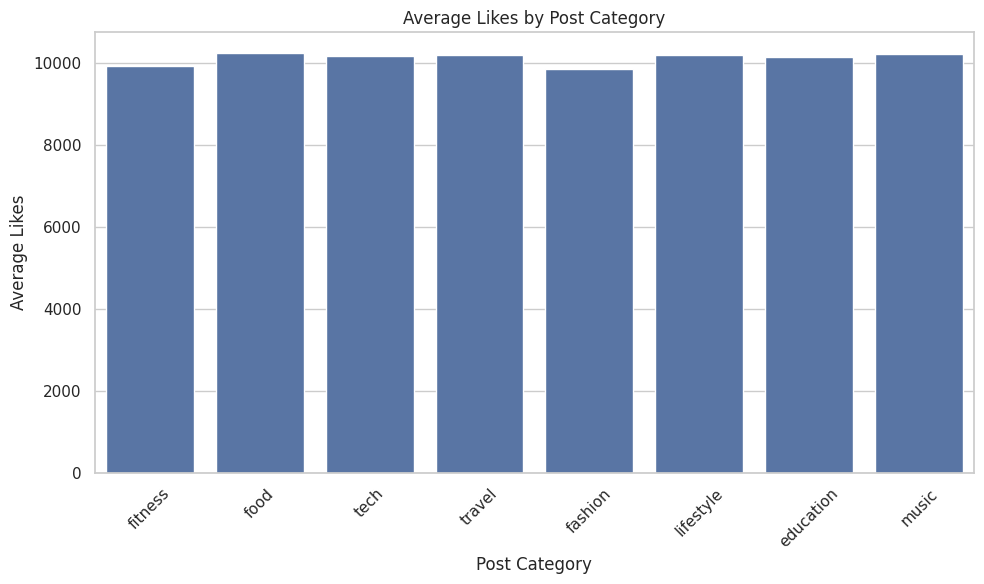

In [ ]:
# ============================================================
# PLOT 8 – SEABORN BAR PLOT
# Average Likes by Post Category
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean",
    errorbar=None
)

plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Visualization 9 — Violin Plot

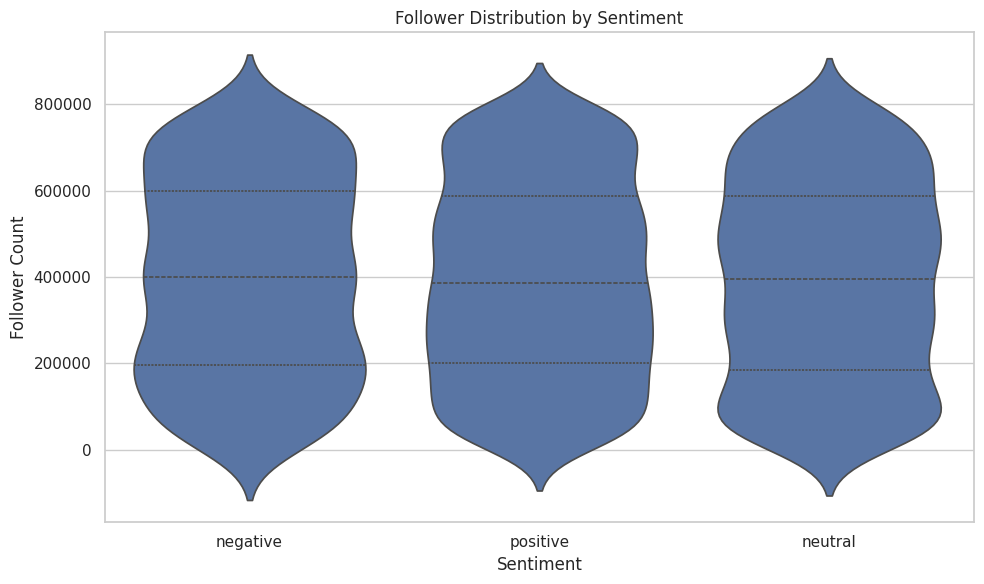

In [ ]:
# ============================================================
# PLOT 9 – SEABORN VIOLIN PLOT
# Followers vs Sentiment
# ============================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count",
    inner="quartile"
)

plt.title("Follower Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")

plt.tight_layout()
plt.show()

###Visualization 10 — Pair Plot

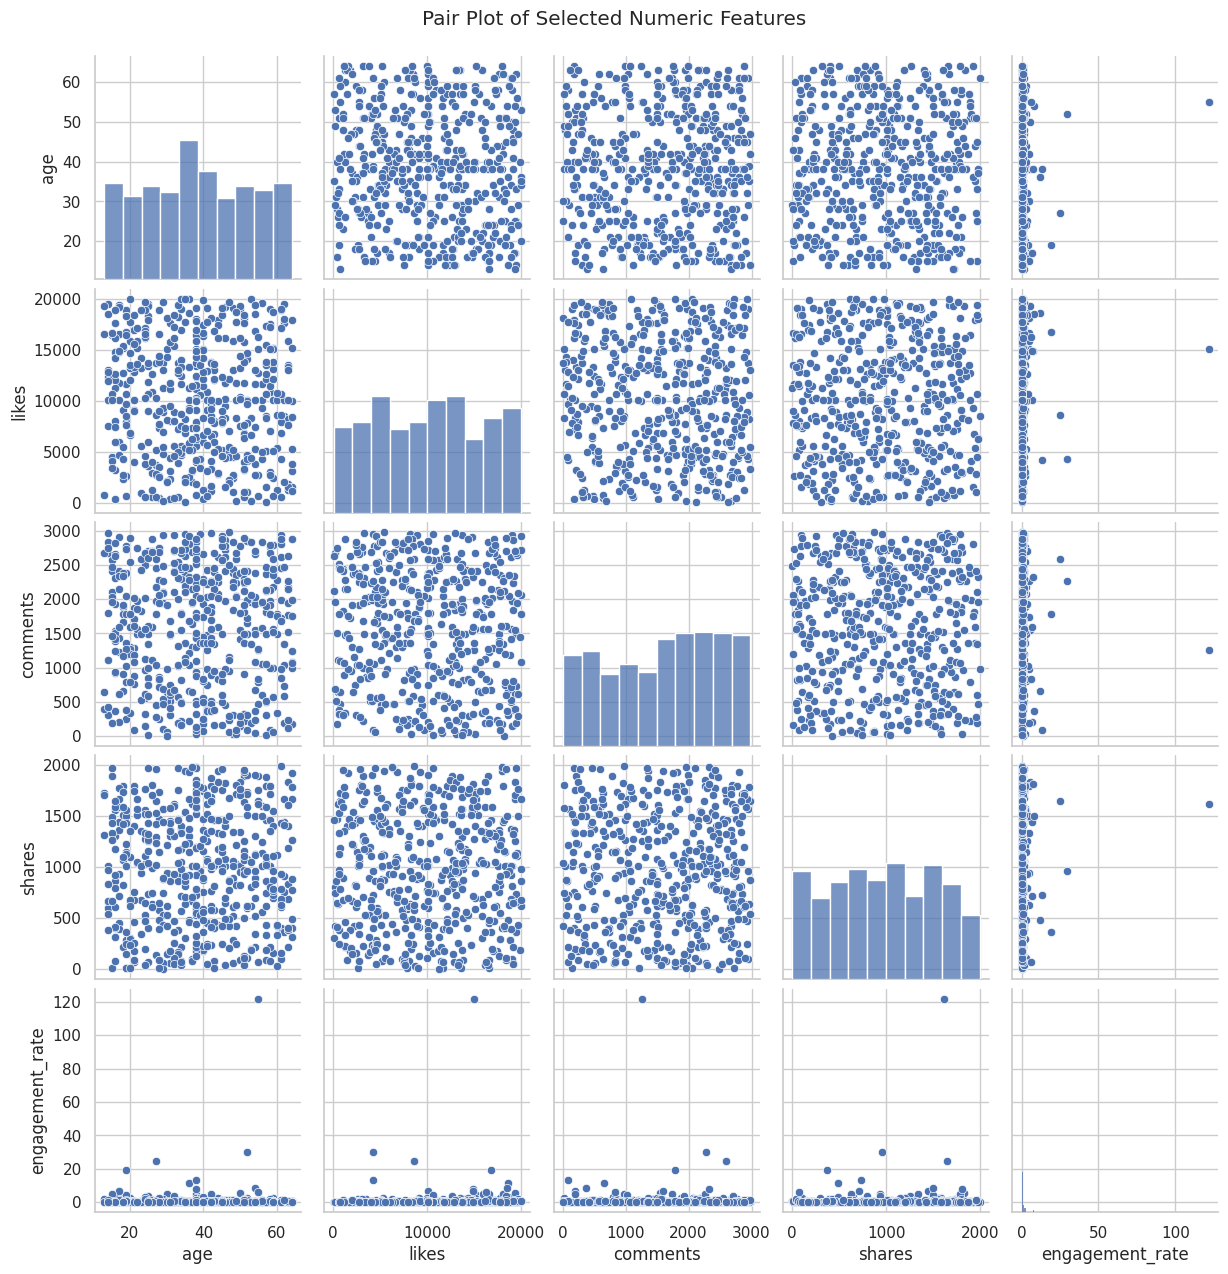

In [ ]:
# ============================================================
# PLOT 10 – SEABORN PAIR PLOT
# Relationships Among Numeric Features
# ============================================================

pair_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "engagement_rate"
]

pair_sample = df[pair_columns].dropna().sample(
    n=min(500, len(df)),
    random_state=42
)

sns.pairplot(
    pair_sample
)

plt.suptitle(
    "Pair Plot of Selected Numeric Features",
    y=1.02
)

plt.show()

###visualization-11 Hearmap

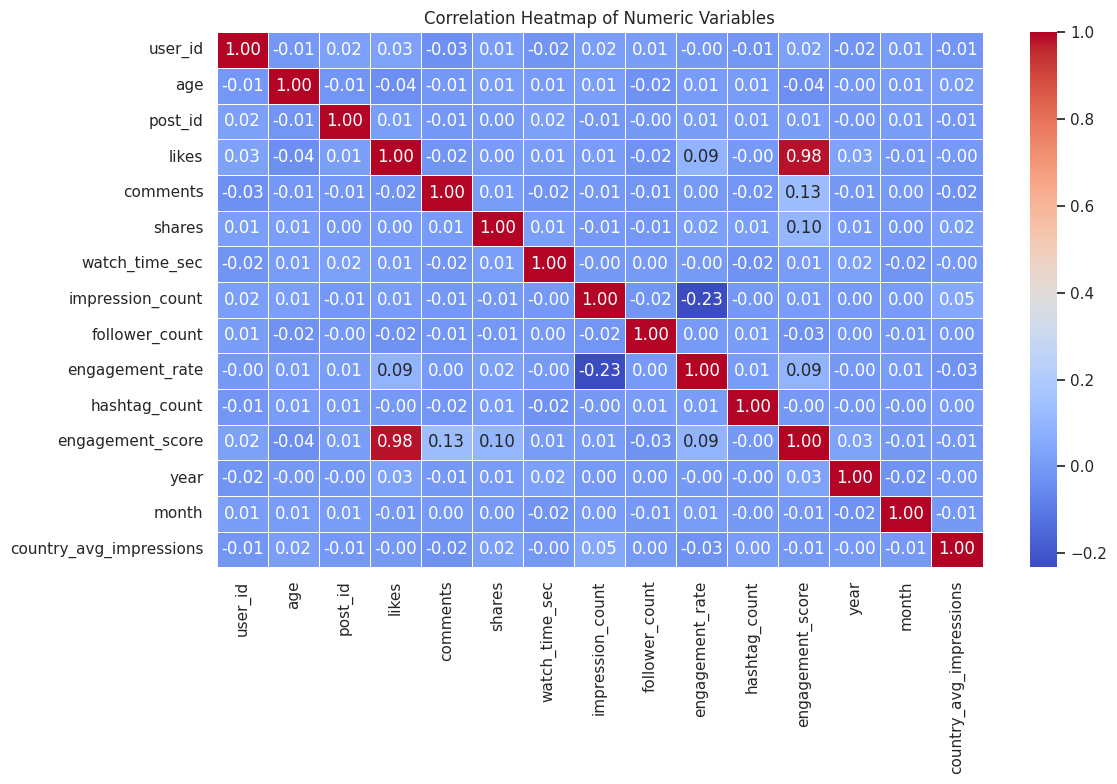

In [ ]:
# ============================================================
# PLOT 11 – SEABORN HEATMAP
# Correlation Matrix
# ============================================================

numeric_data = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables")

plt.tight_layout()
plt.show()

###Visualization 12 — Swarm Plot

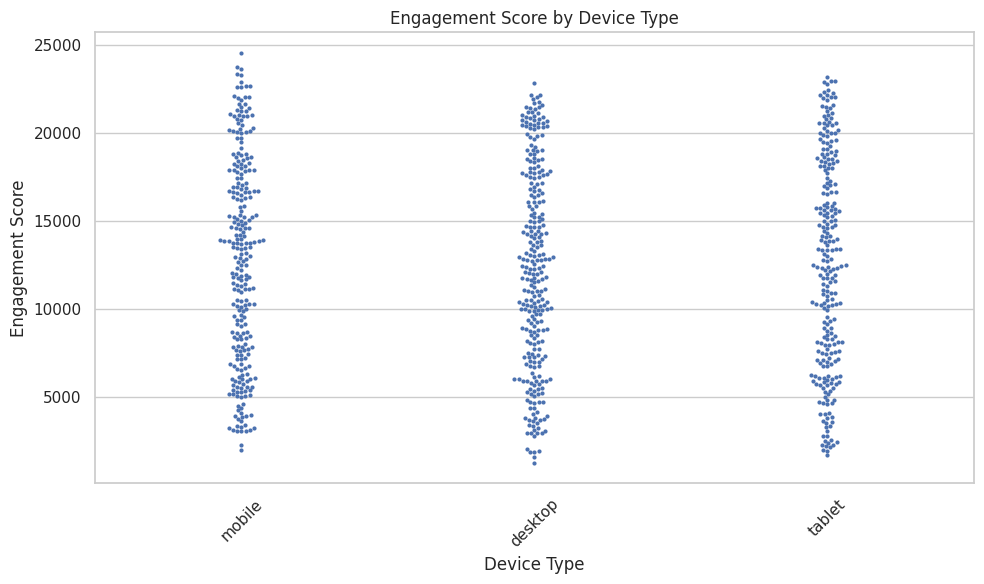

In [ ]:
# ============================================================
# PLOT 12 – SEABORN SWARM PLOT
# Engagement Score by Device Type
# ============================================================

swarm_data = df[
    ["device_type", "engagement_score"]
].dropna().sample(
    n=min(800, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=swarm_data,
    x="device_type",
    y="engagement_score",
    size=3
)

plt.title("Engagement Score by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Visualization 13 — Interactive Plotly Chart

In [ ]:
# ============================================================
# PLOT 13 – PLOTLY INTERACTIVE SCATTER
# Likes vs Impressions by Post Type
# ============================================================

fig = px.scatter(
    df,
    x="impression_count",
    y="likes",
    color="post_type",
    size="engagement_score",
    hover_data=[
        "post_category",
        "country",
        "sentiment"
    ],
    title="Interactive: Likes vs Impressions"
)

fig.update_layout(
    xaxis_title="Impressions",
    yaxis_title="Likes",
    legend_title="Post Type"
)

fig.show()

# Final Insights

This section summarizes the key findings from the social media engagement
analysis and identifies important patterns in content performance, user
behavior, device usage, and sentiment.

## Content Performance Analysis

This analysis identifies the post types and content categories associated
with higher engagement and compares average engagement rates across countries.

###Content Performance Analysis

In [ ]:
# ============================================================
# CONTENT PERFORMANCE ANALYSIS
# ============================================================

# Make sure engagement_score exists.
# If it was already created in Task 4, the existing column is used.
if "engagement_score" not in df.columns:
    df["engagement_score"] = (
        df["likes"].fillna(0)
        + df["comments"].fillna(0)
        + df["shares"].fillna(0)
    )

# ------------------------------------------------------------
# 1. Average Engagement by Post Type
# ------------------------------------------------------------

post_type_analysis = (
    df.groupby("post_type")["engagement_score"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average Engagement Score")
)

print("1. AVERAGE ENGAGEMENT BY POST TYPE")
print("=" * 60)

display(post_type_analysis)

highest_post_type = post_type_analysis.index[0]

print(
    f"Highest-engagement post type: {highest_post_type}"
)


# ------------------------------------------------------------
# 2. Average Engagement by Content Category
# ------------------------------------------------------------

category_analysis = (
    df.groupby("post_category")["engagement_score"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average Engagement Score")
)

print("\n2. AVERAGE ENGAGEMENT BY CONTENT CATEGORY")
print("=" * 60)

display(category_analysis)

best_category = category_analysis.index[0]

print(
    f"Best-performing content category: {best_category}"
)


# ------------------------------------------------------------
# 3. Average Engagement Rate by Country
# ------------------------------------------------------------

country_analysis = (
    df.groupby("country")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average Engagement Rate")
)

print("\n3. TOP COUNTRIES BY AVERAGE ENGAGEMENT RATE")
print("=" * 60)

display(country_analysis.head(10))

top_country = country_analysis.index[0]

print(
    f"Country with the highest average engagement rate: {top_country}"
)

1. AVERAGE ENGAGEMENT BY POST TYPE


,Average Engagement Score
post_type,
video,12664.594286
image,12649.390537
text,12613.243775
reel,12524.031567


Highest-engagement post type: video

2. AVERAGE ENGAGEMENT BY CONTENT CATEGORY


,Average Engagement Score
post_category,
music,12788.549606
food,12739.200675
tech,12686.490226
travel,12650.559167
lifestyle,12639.539539
education,12578.270206
fitness,12457.791852
fashion,12356.420875


Best-performing content category: music

3. TOP COUNTRIES BY AVERAGE ENGAGEMENT RATE


,Average Engagement Rate
country,
brazil,1.540704
australia,1.324339
france,1.146402
uae,1.112352
canada,0.916659
uk,0.850966
japan,0.769623
germany,0.759000
india,0.655005


Country with the highest average engagement rate: brazil


##User Trends – Age and Engagement

The relationship between age and engagement is analyzed using correlation
and age-group comparisons.

In [ ]:
# ============================================================
# AGE AND ENGAGEMENT ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Correlation between Age and Engagement
# ------------------------------------------------------------

age_correlation = (
    df[["age", "engagement_score"]]
    .corr()
    .loc["age", "engagement_score"]
)

print("1. CORRELATION BETWEEN AGE AND ENGAGEMENT")
print("=" * 60)
print(f"Correlation coefficient: {age_correlation:.3f}")


if age_correlation > 0.3:
    age_interpretation = "a positive relationship"
elif age_correlation < -0.3:
    age_interpretation = "a negative relationship"
else:
    age_interpretation = "a weak relationship"

print(f"Interpretation: The data shows {age_interpretation}.")


# ------------------------------------------------------------
# 2. Engagement by Age Group
# ------------------------------------------------------------

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=[
        "Under 18",
        "18–25",
        "26–35",
        "36–45",
        "46–55",
        "56+"
    ]
)

age_group_analysis = (
    df.groupby("age_group", observed=True)["engagement_score"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average Engagement Score")
)

print("\n2. AVERAGE ENGAGEMENT BY AGE GROUP")
print("=" * 60)

display(age_group_analysis)

best_age_group = age_group_analysis.index[0]

print(
    f"Age group with the highest average engagement: {best_age_group}"
)

1. CORRELATION BETWEEN AGE AND ENGAGEMENT
Correlation coefficient: -0.036
Interpretation: The data shows a weak relationship.

2. AVERAGE ENGAGEMENT BY AGE GROUP


,Average Engagement Score
age_group,
Under 18,12991.711538
26–35,12768.703874
36–45,12741.579461
18–25,12628.408385
46–55,12373.489663
56+,12261.744005


Age group with the highest average engagement: Under 18


##Verified vs Unverified Accounts

This analysis compares engagement performance between verified and
unverified accounts.

In [ ]:
# ============================================================
# VERIFIED VS UNVERIFIED ACCOUNT ANALYSIS
# ============================================================

verified_analysis = (
    df.groupby("is_verified")["engagement_score"]
      .mean()
      .to_frame("Average Engagement Score")
)

print("VERIFIED VS UNVERIFIED ACCOUNTS")
print("=" * 60)

display(verified_analysis)

verified_mean = (
    df.loc[df["is_verified"] == True, "engagement_score"]
      .mean()
)

unverified_mean = (
    df.loc[df["is_verified"] == False, "engagement_score"]
      .mean()
)

print(f"Verified accounts average engagement: {verified_mean:.2f}")
print(f"Unverified accounts average engagement: {unverified_mean:.2f}")

if verified_mean > unverified_mean:
    print("Verified accounts have higher average engagement.")
elif verified_mean < unverified_mean:
    print("Unverified accounts have higher average engagement.")
else:
    print("Both account types have the same average engagement.")

VERIFIED VS UNVERIFIED ACCOUNTS


,Average Engagement Score
is_verified,
False,12644.311822
True,12309.280538


Verified accounts average engagement: 12309.28
Unverified accounts average engagement: 12644.31
Unverified accounts have higher average engagement.


##Behavioral Insights – Best Time of Day

The assignment requests analysis of the best time of day for impressions.
However, the provided dataset contains the posting date in `posted_at` but
does not contain an actual posting time or hour.

Therefore, a reliable best-time-of-day analysis cannot be calculated from
the available data without making unsupported assumptions.

In [ ]:
# ============================================================
# BEST TIME OF DAY FOR IMPRESSIONS
# ============================================================

print("BEST TIME OF DAY FOR IMPRESSIONS")
print("=" * 60)

print(
    "The dataset contains posting dates but does not contain "
    "an actual posting time/hour."
)

print(
    "Therefore, the best time of day for impressions cannot be "
    "reliably determined from the provided data."
)

BEST TIME OF DAY FOR IMPRESSIONS
The dataset contains posting dates but does not contain an actual posting time/hour.
Therefore, the best time of day for impressions cannot be reliably determined from the provided data.


##Behavioral Insights – Device Type and Watch Time

This analysis compares average watch time across different device types.

In [ ]:
# ============================================================
# DEVICE TYPE IMPACT ON WATCH TIME
# ============================================================

device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average Watch Time (seconds)")
)

print("AVERAGE WATCH TIME BY DEVICE TYPE")
print("=" * 60)

display(device_watch_time)

best_device = device_watch_time.index[0]

print(
    f"Device type with the highest average watch time: {best_device}"
)

AVERAGE WATCH TIME BY DEVICE TYPE


,Average Watch Time (seconds)
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


Device type with the highest average watch time: mobile


##Sentiment Analysis

This section examines which sentiment performs best and compares the
behavior of negative and neutral sentiment posts.

In [ ]:
# ============================================================
# SENTIMENT PERFORMANCE ANALYSIS
# ============================================================

sentiment_analysis = (
    df.groupby("sentiment")
      .agg(
          Average_Engagement=("engagement_score", "mean"),
          Average_Likes=("likes", "mean"),
          Average_Comments=("comments", "mean"),
          Average_Shares=("shares", "mean"),
          Average_Impressions=("impression_count", "mean")
      )
      .sort_values(
          "Average_Engagement",
          ascending=False
      )
)

print("SENTIMENT PERFORMANCE")
print("=" * 60)

display(sentiment_analysis)

best_sentiment = sentiment_analysis.index[0]

print(
    f"Best-performing sentiment: {best_sentiment}"
)

SENTIMENT PERFORMANCE


,Average_Engagement,Average_Likes,Average_Comments,Average_Shares,Average_Impressions
sentiment,,,,,
negative,12731.498958,10208.096875,1516.094792,1007.307292,50191.960417
positive,12665.799443,10180.062077,1480.650617,1005.086749,50248.107441
neutral,12448.163720,9923.194499,1528.404060,996.565160,49515.971185


Best-performing sentiment: negative


In [ ]:
# ============================================================
# NEGATIVE VS NEUTRAL SENTIMENT ANALYSIS
# ============================================================

negative_neutral = (
    df[df["sentiment"].isin(["negative", "neutral"])]
    .groupby("sentiment")
    .agg(
        Average_Engagement=("engagement_score", "mean"),
        Average_Likes=("likes", "mean"),
        Average_Comments=("comments", "mean"),
        Average_Shares=("shares", "mean"),
        Average_Impressions=("impression_count", "mean")
    )
)

print("NEGATIVE VS NEUTRAL SENTIMENT POSTS")
print("=" * 60)

display(negative_neutral)

NEGATIVE VS NEUTRAL SENTIMENT POSTS


,Average_Engagement,Average_Likes,Average_Comments,Average_Shares,Average_Impressions
sentiment,,,,,
negative,12731.498958,10208.096875,1516.094792,1007.307292,50191.960417
neutral,12448.163720,9923.194499,1528.404060,996.565160,49515.971185


In [ ]:
# ============================================================
# FINAL KEY FINDINGS SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Analysis": [
        "Highest-engagement post type",
        "Best-performing content category",
        "Highest average engagement-rate country",
        "Highest-engagement age group",
        "Highest watch-time device",
        "Best-performing sentiment"
    ],
    "Finding": [
        highest_post_type,
        best_category,
        top_country,
        best_age_group,
        best_device,
        best_sentiment
    ]
})

display(summary)

,Analysis,Finding
0,Highest-engagement post type,video
1,Best-performing content category,music
2,Highest average engagement-rate country,brazil
3,Highest-engagement age group,Under 18
4,Highest watch-time device,mobile
5,Best-performing sentiment,negative


###Final Dataset Check

In [ ]:
# ============================================================
# FINAL DATASET QUALITY CHECK
# ============================================================

print("=" * 70)
print("FINAL DATASET QUALITY CHECK")
print("=" * 70)

# 1. Dataset shape
print("\n1. DATASET SHAPE")
print("-" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# 2. Missing values
print("\n2. MISSING VALUES")
print("-" * 70)

missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values[missing_values > 0])

print(f"\nTotal missing values: {missing_values.sum()}")

# 3. Duplicate rows
print("\n3. DUPLICATE ROWS")
print("-" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

# 4. Data types
print("\n4. DATA TYPES")
print("-" * 70)

print(df.dtypes)

# 5. Final column names
print("\n5. FINAL COLUMN NAMES")
print("-" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# 6. Final preview
print("\n6. FINAL DATASET PREVIEW")
print("-" * 70)

display(df.head())

# 7. Final verification
print("\n" + "=" * 70)

if missing_values.sum() == 0 and duplicate_count == 0:
    print("FINAL CHECK PASSED")
    print("✓ No missing values")
    print("✓ No duplicate rows")
    print("✓ Dataset is ready for submission")
else:
    print("FINAL CHECK REQUIRES ATTENTION")
    print("Please review the missing values or duplicate rows above.")

print("=" * 70)

FINAL DATASET QUALITY CHECK

1. DATASET SHAPE
----------------------------------------------------------------------
Rows    : 5000
Columns : 27

2. MISSING VALUES
----------------------------------------------------------------------
No missing values found.

Total missing values: 0

3. DUPLICATE ROWS
----------------------------------------------------------------------
Duplicate rows: 0

4. DATA TYPES
----------------------------------------------------------------------
user_id                             int64
age                               float64
gender                             object
country                            object
post_id                             int64
post_type                          object
post_category                      object
likes                             float64
comments                          float64
shares                            float64
watch_time_sec                      int64
impression_count                    int64
posted_at        

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,year,month,month_name,day_of_week,country_avg_impressions,age_group
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0,2022,12,December,Saturday,49193.174603,36–45
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0,2023,6,June,Friday,49193.174603,26–35
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0,2023,5,May,Sunday,51119.393509,26–35
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0,2023,2,February,Sunday,51727.673387,46–55
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0,2023,5,May,Tuesday,51119.393509,26–35



FINAL CHECK PASSED
✓ No missing values
✓ No duplicate rows
✓ Dataset is ready for submission


# Final Conclusion

The Social Media Engagement Analysis project successfully examined
social media data using Python, Pandas, NumPy, Matplotlib, Seaborn,
and Plotly.

The analysis covered data loading, data cleaning, missing-value
handling, duplicate removal, data formatting, feature engineering,
exploratory data analysis, statistical analysis, and data visualization.

The analysis provided insights into content performance, user trends,
country-level engagement, device usage, account verification, and
sentiment.

The visualizations helped identify relationships between impressions,
likes, engagement, age, followers, sentiment, post categories, post
types, and device types.

The final cleaned dataset was checked for missing values and duplicate
records before being saved for further use.

Overall, this project demonstrates how raw social media data can be
cleaned, analyzed, visualized, and transformed into meaningful insights
that can support better social media content and engagement strategies.

In [ ]:
# ============================================================
# SAVE FINAL CLEANED DATASET
# ============================================================

output_file = "social_media_engagement_5000_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("=" * 70)
print("CLEANED DATASET SAVED SUCCESSFULLY")
print("=" * 70)

print(f"\nFile name: {output_file}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

CLEANED DATASET SAVED SUCCESSFULLY

File name: social_media_engagement_5000_cleaned.csv
Rows: 5000
Columns: 27


In [ ]:
# ============================================================
# VERIFY SAVED CLEANED DATASET
# ============================================================

import os

if os.path.exists(output_file):

    saved_df = pd.read_csv(output_file)

    print("=" * 70)
    print("SAVED FILE VERIFICATION")
    print("=" * 70)

    print(f"\nFile exists       : Yes")
    print(f"File name         : {output_file}")
    print(f"Saved rows        : {saved_df.shape[0]}")
    print(f"Saved columns     : {saved_df.shape[1]}")
    print(f"Missing values    : {saved_df.isnull().sum().sum()}")
    print(f"Duplicate rows    : {saved_df.duplicated().sum()}")

    print("\nSaved dataset preview:")
    display(saved_df.head())

else:
    print("File was not found. Please run the save cell again.")

SAVED FILE VERIFICATION

File exists       : Yes
File name         : social_media_engagement_5000_cleaned.csv
Saved rows        : 5000
Saved columns     : 27
Missing values    : 0
Duplicate rows    : 0

Saved dataset preview:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,year,month,month_name,day_of_week,country_avg_impressions,age_group
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0,2022,12,December,Saturday,49193.174603,36–45
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0,2023,6,June,Friday,49193.174603,26–35
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0,2023,5,May,Sunday,51119.393509,26–35
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0,2023,2,February,Sunday,51727.673387,46–55
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0,2023,5,May,Tuesday,51119.393509,26–35


In [ ]:
# ============================================================
# DOWNLOAD CLEANED DATASET
# ============================================================

from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>